**Likith N A - 2460825**

likith.na@btech.christuniversity.in

Class - 5BTCS C

# Currency Recognition System — Capstone Training Notebook
### Samsung Innovation Campus AIML Course

**What this notebook does, step by step:**
1. Connect to Kaggle and download the *Indian Currency Banknotes Dataset*
2. Explore the data — how many images per denomination, what they look like
3. Split the data into train / validation / test sets
4. Build an image pipeline with data augmentation
5. Build a CNN using **transfer learning** (MobileNetV2 pretrained on ImageNet)
6. Train in two phases: frozen base → fine-tuning
7. Evaluate the model — accuracy, confusion matrix, per-class report
8. Save the trained model + class labels so the Streamlit app can use them

**Before you run anything:** in Colab, go to `Runtime -> Change runtime type -> T4 GPU`.
Training on a CPU will work but will be much slower.


## Step 1 — Install & import libraries

`kaggle` lets us download the dataset straight into Colab using an API key.
`tensorflow` is our deep learning framework. `split-folders` will handle the
train/val/test split for us. `scikit-learn` and `seaborn` are for evaluation
and plotting.

In [1]:
!pip install -q kaggle split-folders

import os, json, shutil, pathlib, random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Step 2 — Get the dataset from Kaggle

You need a Kaggle API token (a small file called `kaggle.json`):
1. Go to https://www.kaggle.com/settings
2. Scroll to **API** -> click **Create New Token** — this downloads `kaggle.json`
3. Run the cell below and upload that file when prompted

This authenticates the `kaggle` CLI so it can download the dataset on your behalf.

In [2]:
from getpass import getpass
import os

kaggle_token = getpass("KGAT_32d20451bc023e2d3449c420211803ff").strip()

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/access_token', 'w') as f:
    f.write(kaggle_token)
os.chmod('/root/.kaggle/access_token', 0o600)
os.environ['KAGGLE_API_TOKEN'] = kaggle_token

print("Token saved — testing authentication...")
!kaggle datasets list -s "indian currency"

KGAT_32d20451bc023e2d3449c420211803ff··········
Token saved — testing authentication...
ref                                                     title                                             size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------  ------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
gauravsahani/indian-currency-notes-classifier           Indian Currency Notes Classifier              21008172  2020-07-05 13:13:13.933000           7605         77  0.75             
yashdogra/2000-notes                                    Indian Currency Banknotes Dataset             20644672  2025-04-01 09:05:02.913000            236         12  1                
shobhit18th/indian-currency-notes                       Indian currency notes                        304242348  2019-12-06 12:49:44.460000           2108         40  0.3125    

### Switching to a Larger Dataset

You've found a much larger dataset which is great! This section will replace the old dataset with the new one. After running this, remember to re-run all subsequent data processing and training cells.

In [3]:
DATA_DIR = pathlib.Path('/content/data')

def list_tree(path, prefix='', max_depth=3, depth=0):
    if depth > max_depth:
        return
    for p in sorted(path.iterdir()):
        print(prefix + p.name)
        if p.is_dir() and depth < max_depth:
            list_tree(p, prefix + '  ', max_depth, depth + 1)

list_tree(DATA_DIR)

Datasets
  fifty_new
    IMG_1666262689009.jpg
    IMG_1666262695803.jpg
    IMG_1666262703140.jpg
    IMG_1666262722913.jpg
    IMG_1666262736935.jpg
    IMG_1666262744203.jpg
    IMG_1666262755277.jpg
    IMG_1666262770090.jpg
    IMG_1666262795768.jpg
    IMG_1666262814583.jpg
    IMG_1666262835095.jpg
    IMG_1666262856012.jpg
    IMG_1666262866015.jpg
    IMG_1666262884651.jpg
    IMG_1666262889322.jpg
    IMG_1666262894673.jpg
    IMG_1666262915130.jpg
    IMG_1666262955616.jpg
    IMG_1666262961222.jpg
    IMG_1666262978310.jpg
    IMG_1666262985528.jpg
    IMG_1666263021052.jpg
    IMG_1666263027073.jpg
    IMG_1666263044938.jpg
    IMG_1666263052730.jpg
    IMG_1666263077650.jpg
    IMG_1666263084639.jpg
    IMG_1666263092682.jpg
    IMG_1666263096717.jpg
    IMG_1666263109781.jpg
    IMG_1666263114412.jpg
    IMG_1666263182866.jpg
    IMG_1666263189708.jpg
    IMG_1666263210216.jpg
    IMG_1666263214900.jpg
    IMG_1666263231953.jpg
    IMG_1666263259711.jpg
    IMG_166626326

In [4]:
# Remove the old dataset directory to make way for the new one
if DATA_DIR.exists():
    print(f"Removing existing data directory: {DATA_DIR}")
    shutil.rmtree(DATA_DIR)
    print("Old data removed.")

# Recreate DATA_DIR as it was removed
os.makedirs(DATA_DIR, exist_ok=True)

# Download the new, larger dataset
print(f"Downloading new dataset: apoorvshekher/indian-currency-dataset to {DATA_DIR}")
!kaggle datasets download -d apoorvshekher/indian-currency-dataset -p {DATA_DIR} --unzip

print("New dataset downloaded and unzipped.")

# Verify the new structure (optional, but good for debugging)
print("\nNew dataset structure:")
list_tree(DATA_DIR)

Removing existing data directory: /content/data
Old data removed.
Dataset URL: https://www.kaggle.com/datasets/apoorvshekher/indian-currency-dataset
License(s): CC-BY-NC-SA-4.0
100% 637M/637M [00:07<00:00, 83.6MB/s]

New dataset downloaded and unzipped.

New dataset structure:
Datasets
  fifty_new
    IMG_1666262689009.jpg
    IMG_1666262695803.jpg
    IMG_1666262703140.jpg
    IMG_1666262722913.jpg
    IMG_1666262736935.jpg
    IMG_1666262744203.jpg
    IMG_1666262755277.jpg
    IMG_1666262770090.jpg
    IMG_1666262795768.jpg
    IMG_1666262814583.jpg
    IMG_1666262835095.jpg
    IMG_1666262856012.jpg
    IMG_1666262866015.jpg
    IMG_1666262884651.jpg
    IMG_1666262889322.jpg
    IMG_1666262894673.jpg
    IMG_1666262915130.jpg
    IMG_1666262955616.jpg
    IMG_1666262961222.jpg
    IMG_1666262978310.jpg
    IMG_1666262985528.jpg
    IMG_1666263021052.jpg
    IMG_1666263027073.jpg
    IMG_1666263044938.jpg
    IMG_1666263052730.jpg
    IMG_1666263077650.jpg
    IMG_1666263084639.jpg

**IMPORTANT:** Now that the new dataset is downloaded, you need to **re-run all cells from 'Step 3 — Explore the dataset (EDA)' onwards** to update `DATA_DIR` and process the new images. This includes:

*   `list_tree(DATA_DIR)` (cell `61831b64`)
*   The cells that determine `class_dirs` and counts (cells `7e52efd5` and `b6-gksqf_JTP`)
*   The data restructuring cell (cell `f6faa4d6`), as the new dataset might have a different nesting structure.
*   The `splitfolders` cell (cell `7e9481b1`)
*   All subsequent model building, training, and evaluation cells.

## Step 3 — Explore the dataset (EDA)

Before writing any preprocessing code, we look at what we actually got:
what the folders are called, how many images are in each, and what the
images look like. Kaggle datasets aren't always organised exactly the way
their description implies, so this step avoids assuming a structure that
turns out to be wrong.

**Look at the printed tree above.** You should see one sub-folder per
denomination (e.g. `10`, `20`, `50`, `100`, `200`, `500`, `2000`, possibly
split further into old/new series). Point `IMAGE_ROOT` below at whichever
folder *directly* contains those class folders — if they're nested one
level deeper, add that folder name to the path.

In [5]:
# TODO: adjust this path if list_tree above shows the class folders nested deeper
IMAGE_ROOT = DATA_DIR / 'Datasets'  # Updated for the new dataset structure

class_dirs = [d for d in IMAGE_ROOT.iterdir() if d.is_dir()]
print(f"Found {len(class_dirs)} class folders:")
for d in class_dirs:
    n_images = len(list(d.glob('*.*')))
    print(f"  {d.name}: {n_images} images")

Found 11 class folders:
  two_hundred: 272 images
  hundred_old: 107 images
  fifty_new: 265 images
  two_thousand: 102 images
  twenty_new: 288 images
  hundred_new: 224 images
  five_hundred: 279 images
  ten_new: 345 images
  twenty_old: 257 images
  ten_old: 306 images
  fifty_old: 234 images


In [6]:
for d in class_dirs:
    print(f"\n{d.name}/")
    subdirs = [s for s in d.iterdir() if s.is_dir()]
    if subdirs:
        for s in subdirs:
            n = len(list(s.glob('*.*')))
            print(f"  {s.name}/: {n} files")
            sub_subdirs = [ss for ss in s.iterdir() if ss.is_dir()]
            for ss in sub_subdirs:
                n2 = len(list(ss.glob('*.*')))
                print(f"    {ss.name}/: {n2} files")
    else:
        direct_files = list(d.glob('*.*'))
        print(f"  (no subfolders) {len(direct_files)} files directly here")


two_hundred/
  (no subfolders) 272 files directly here

hundred_old/
  (no subfolders) 107 files directly here

fifty_new/
  (no subfolders) 265 files directly here

two_thousand/
  (no subfolders) 102 files directly here

twenty_new/
  (no subfolders) 288 files directly here

hundred_new/
  (no subfolders) 224 files directly here

five_hundred/
  (no subfolders) 279 files directly here

ten_new/
  (no subfolders) 345 files directly here

twenty_old/
  (no subfolders) 257 files directly here

ten_old/
  (no subfolders) 306 files directly here

fifty_old/
  (no subfolders) 234 files directly here


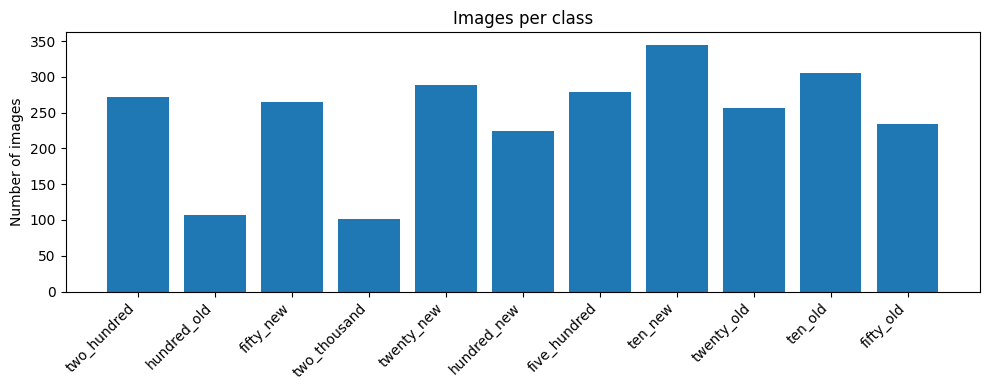

In [8]:
# Class balance check — very uneven classes would need extra handling
# (class weights, oversampling) which we'd rather notice now than after training
counts = {d.name: len(list(d.glob('*.*'))) for d in class_dirs}
plt.figure(figsize=(10, 4))
plt.bar(counts.keys(), counts.values())
plt.xticks(rotation=45, ha='right')
plt.ylabel("Number of images")
plt.title("Images per class")
plt.tight_layout()
plt.show()


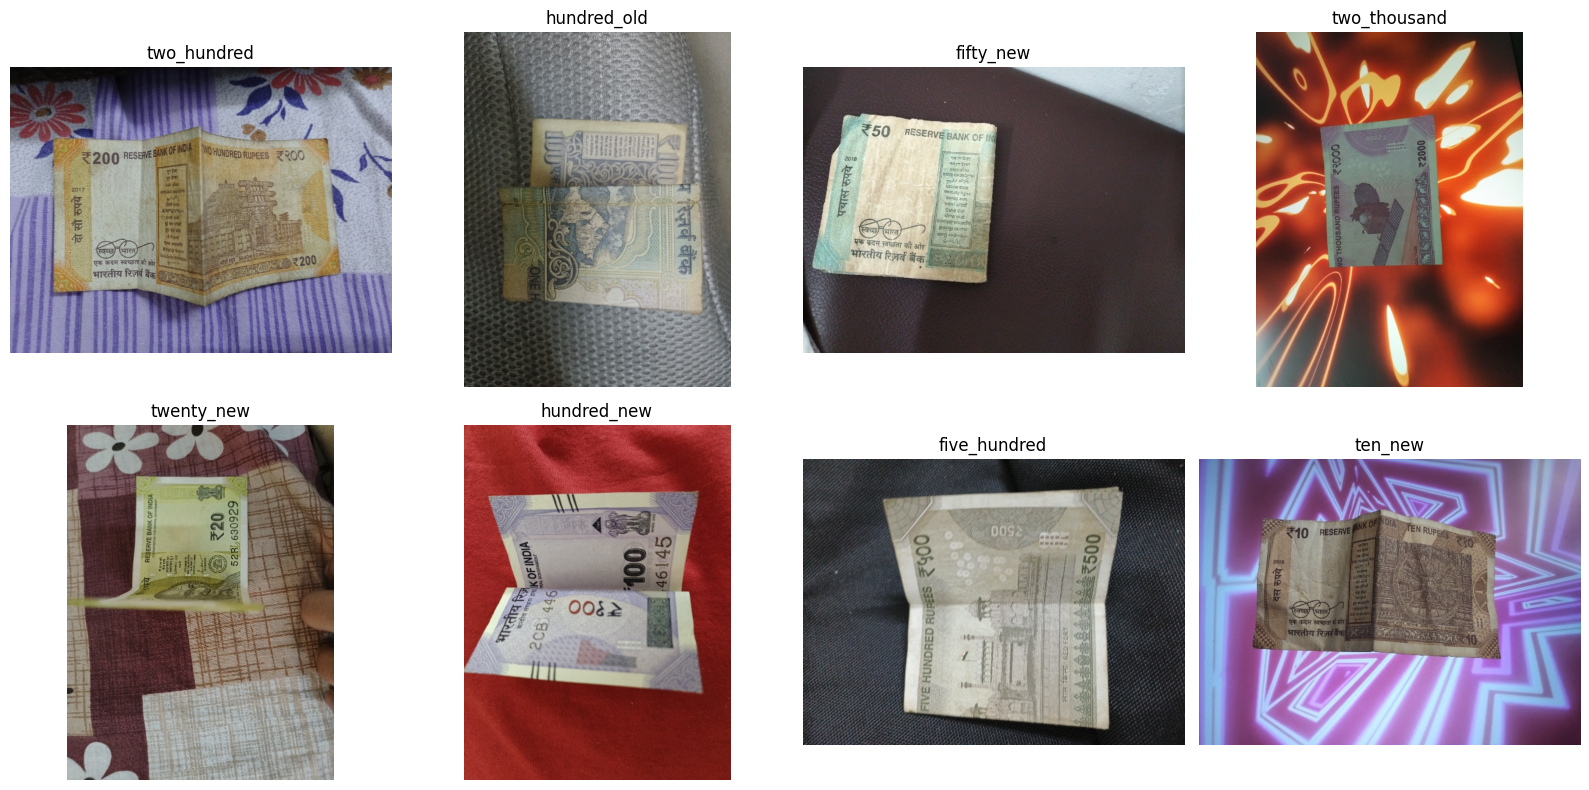

In [9]:
import os

# Eyeball a sample image from each class
n_show = min(8, len(class_dirs))
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

def find_first_image_recursive(path):
    """Recursively finds the path to the first image file in a directory tree."""
    for f in path.iterdir(): # Use iterdir to get files and directories
        if f.is_file() and f.suffix.lower() in ['.jpg', '.jpeg', '.png', '.gif']:
            return f
    for subdir in path.iterdir():
        if subdir.is_dir():
            found_image = find_first_image_recursive(subdir)
            if found_image:
                return found_image
    return None

for ax, d in zip(axes.flat, class_dirs[:n_show]):
    sample_path = find_first_image_recursive(d) # Use the helper function
    if sample_path:
        img = tf.keras.utils.load_img(sample_path)
        ax.imshow(img)
        ax.set_title(d.name)
    else:
        ax.set_title(f"{d.name} (No image found)") # Indicate no image was found
    ax.axis('off')

for ax in axes.flat[n_show:]:
    ax.axis('off')
plt.tight_layout()
plt.show()

## Step 4 — Train / validation / test split

Three separate sets, each with a distinct job:
- **Train** — the model actually learns from these images
- **Validation** — used *during* training to check progress and decide when
  to stop, without ever being learned from directly
- **Test** — touched only once, at the very end, to get an honest score on
  images the model has never influenced its training on

We use a 70/15/15 split. `split-folders` copies files into a new directory
structure that Keras can read directly.

In [10]:
import splitfolders

SPLIT_DIR = '/content/data_split'
splitfolders.ratio(str(IMAGE_ROOT), output=SPLIT_DIR, seed=42, ratio=(.7, .15, .15))

print("New structure:")
list_tree(pathlib.Path(SPLIT_DIR), max_depth=2)

Copying files: 2679 files [00:02, 967.69 files/s] 

New structure:
test
  fifty_new
    IMG_1666262695803.jpg
    IMG_1666262755277.jpg
    IMG_1666262770090.jpg
    IMG_1666262866015.jpg
    IMG_1666262915130.jpg
    IMG_1666263044938.jpg
    IMG_1666263285845.jpg
    IMG_1666263310691.jpg
    IMG_1666263343609.jpg
    IMG_1666265296761.jpg
    IMG_1666265314657.jpg
    IMG_1666265342999.jpg
    IMG_1666265348595.jpg
    IMG_1666265375244.jpg
    IMG_1666265408473.jpg
    IMG_1666265593164.jpg
    IMG_1667847298034.jpg
    IMG_1667847447757.jpg
    IMG_1667847451017.jpg
    IMG_1667847505161.jpg
    IMG_1667847603349.jpg
    IMG_1667847640319.jpg
    IMG_1667847773608.jpg
    IMG_1667847779029.jpg
    IMG_1667847795932.jpg
    IMG_1667847850503.jpg
    IMG_1667847878505.jpg
    IMG_1667848015195.jpg
    IMG_1667848194951.jpg
    IMG_1667848219710.jpg
    IMG_1667848314440.jpg
    IMG_1667851881730.jpg
    IMG_1667851889246.jpg
    IMG_1667851964173.jpg
    IMG_1667851968221.jpg
    IMG_1667852006176.jpg
    IMG_1667852064221.jpg
    IM

## Step 5 — Build the data pipelines

`image_dataset_from_directory` reads images straight from folders and
automatically turns folder names into class labels. We resize every image
to 224x224 because that's the input size MobileNetV2 was trained on.

In [11]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    f'{SPLIT_DIR}/train', image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical')
val_ds = tf.keras.utils.image_dataset_from_directory(
    f'{SPLIT_DIR}/val', image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical')
test_ds = tf.keras.utils.image_dataset_from_directory(
    f'{SPLIT_DIR}/test', image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode='categorical', shuffle=False)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print("Classes:", class_names)

with open('class_names.json', 'w') as f:
    json.dump(class_names, f)


Found 1869 files belonging to 11 classes.
Found 396 files belonging to 11 classes.
Found 414 files belonging to 11 classes.
Classes: ['fifty_new', 'fifty_old', 'five_hundred', 'hundred_new', 'hundred_old', 'ten_new', 'ten_old', 'twenty_new', 'twenty_old', 'two_hundred', 'two_thousand']


**Data augmentation** artificially creates more training variety by
lightly rotating/zooming/adjusting brightness — this helps the model
generalise instead of memorising the exact 1,400 or so training images.

Notice there's **no horizontal flip**. Flipping a currency note mirrors the
portrait and text, which never happens in a real photo — training on
flipped notes would teach the model a pattern that doesn't exist in
reality and could hurt real-world accuracy.

In [12]:
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
    layers.RandomBrightness(0.15),
], name="data_augmentation")

AUTOTUNE = tf.data.AUTOTUNE

# MobileNetV3 uses a specific preprocessing function
def preprocess(image, label):
    image = tf.keras.applications.mobilenet_v3.preprocess_input(image)
    return image, label

train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                         num_parallel_calls=AUTOTUNE)
train_ds = train_ds.map(preprocess, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds = val_ds.map(preprocess, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_ds = test_ds.map(preprocess, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

## Step 6 — Build the model (transfer learning)

**Why transfer learning?** MobileNetV2 has already been trained on over a
million ImageNet images and has learned general-purpose visual features —
edges, textures, shapes, colour patterns. Re-learning all of that from
~1,400 currency images would need far more data and compute than we have.
Instead we reuse MobileNetV2's "vision" as a frozen feature extractor and
train only a small classification head on top for our specific classes.

In [13]:
# Switching to MobileNetV3Large as requested
base_model = tf.keras.applications.MobileNetV3Large(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze for Phase 1

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 7, 7, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 960)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 11)             │        10,571 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,006,923 (11.47 MB)

 Trainable params: 10,571 (41.29 KB)

 Non-trainable params: 2,996,352 (11.43 MB)

### Class weighting

The classification report showed the weakest recall on `fifty_old` and `hundred_old` — both have fewer training images than the other classes. Class weights make mistakes on under-represented classes "cost" more during training, nudging the model to pay them more attention instead of optimizing mainly for the larger classes.

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

# Count images per class directly from the train split on disk so this
# lines up exactly with class_names (both come from the same folders).
train_dir = pathlib.Path(SPLIT_DIR) / 'train'
y_train_labels = []
for idx, cname in enumerate(class_names):
    n = len(list((train_dir / cname).glob('*.*')))
    y_train_labels += [idx] * n

class_weight_values = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=np.array(y_train_labels)
)
class_weight_dict = {i: w for i, w in enumerate(class_weight_values)}
print("Class weights:")
for cname, i in zip(class_names, range(NUM_CLASSES)):
    print(f"  {cname}: {class_weight_dict[i]:.2f}")


## Step 7 — Phase 1 training (frozen base)

Callbacks keep training healthy automatically:
- **EarlyStopping** — stop once validation accuracy stops improving, and
  restore the best-performing weights (prevents overfitting from
  training too long)
- **ModelCheckpoint** — save the best version seen so far, just in case
- **ReduceLROnPlateau** — shrink the learning rate if progress stalls

In [14]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy'),
    tf.keras.callbacks.ModelCheckpoint('best_phase1.keras', save_best_only=True, monitor='val_accuracy'),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3),
]

EPOCHS_PHASE1 = 15

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE1,
    callbacks=callbacks,
    class_weight=class_weight_dict
)


Epoch 1/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 80s 977ms/step - accuracy: 0.2376 - loss: 2.3531 - val_accuracy: 0.4975 - val_loss: 1.5322 - learning_rate: 0.0010
Epoch 2/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 29s 482ms/step - accuracy: 0.5040 - loss: 1.4534 - val_accuracy: 0.6591 - val_loss: 1.1052 - learning_rate: 0.0010
Epoch 3/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 27s 447ms/step - accuracy: 0.6399 - loss: 1.0701 - val_accuracy: 0.7197 - val_loss: 0.8959 - learning_rate: 0.0010
Epoch 4/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 39s 400ms/step - accuracy: 0.7207 - loss: 0.8917 - val_accuracy: 0.7702 - val_loss: 0.7335 - learning_rate: 0.0010
Epoch 5/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 41s 410ms/step - accuracy: 0.7624 - loss: 0.7374 - val_accuracy: 0.7727 - val_loss: 0.6672 - learning_rate: 0.0010
Epoch 6/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 24s 407ms/step - accuracy: 0.8213 - loss: 0.6391 - val_accuracy: 0.8157 - val_loss: 0.5875 - learning_rate: 0.0010
Epoch 7/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 41s 409ms/step - accuracy: 0.8406 - loss: 0.

## Step 8 — Phase 2: fine-tuning

Now we unfreeze the top layers of MobileNetV2 and let them adjust slightly
to our specific currency images. We keep the earlier layers frozen (they
hold generic, universally-useful features like edge detectors) and only
fine-tune the later, more task-specific layers. The learning rate is
dropped to 1e-5 — a big learning rate here would wreck the pretrained
weights instead of gently adapting them.

In [15]:
base_model.trainable = True

# MobileNetV3Large has ~263 layers.
# We'll freeze the first 200 layers and fine-tune the rest.
FINE_TUNE_AT = 200

for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

EPOCHS_PHASE2 = 20
total_epochs = EPOCHS_PHASE1 + EPOCHS_PHASE2

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=total_epochs,
    initial_epoch=history1.epoch[-1] + 1,
    callbacks=callbacks,
    class_weight=class_weight_dict
)

Epoch 16/25
59/59 ━━━━━━━━━━━━━━━━━━━━ 51s 653ms/step - accuracy: 0.9219 - loss: 0.3104 - val_accuracy: 0.8939 - val_loss: 0.3448 - learning_rate: 1.0000e-05
Epoch 17/25
59/59 ━━━━━━━━━━━━━━━━━━━━ 24s 398ms/step - accuracy: 0.9090 - loss: 0.3189 - val_accuracy: 0.8939 - val_loss: 0.3421 - learning_rate: 1.0000e-05
Epoch 18/25
59/59 ━━━━━━━━━━━━━━━━━━━━ 22s 375ms/step - accuracy: 0.9101 - loss: 0.3256 - val_accuracy: 0.8914 - val_loss: 0.3402 - learning_rate: 1.0000e-05
Epoch 19/25
59/59 ━━━━━━━━━━━━━━━━━━━━ 25s 415ms/step - accuracy: 0.9080 - loss: 0.3264 - val_accuracy: 0.8990 - val_loss: 0.3386 - learning_rate: 1.0000e-05
Epoch 20/25
59/59 ━━━━━━━━━━━━━━━━━━━━ 39s 379ms/step - accuracy: 0.8983 - loss: 0.3293 - val_accuracy: 0.8990 - val_loss: 0.3378 - learning_rate: 1.0000e-05
Epoch 21/25
59/59 ━━━━━━━━━━━━━━━━━━━━ 43s 406ms/step - accuracy: 0.9106 - loss: 0.3295 - val_accuracy: 0.8990 - val_loss: 0.3371 - learning_rate: 1.0000e-05
Epoch 22/25
59/59 ━━━━━━━━━━━━━━━━━━━━ 40s 393ms/ste

## Step 9 — Plot training curves

If validation accuracy tracks training accuracy closely, the model is
generalising well. A big, growing gap between them is the classic sign of
overfitting — worth mentioning in your project report either way.

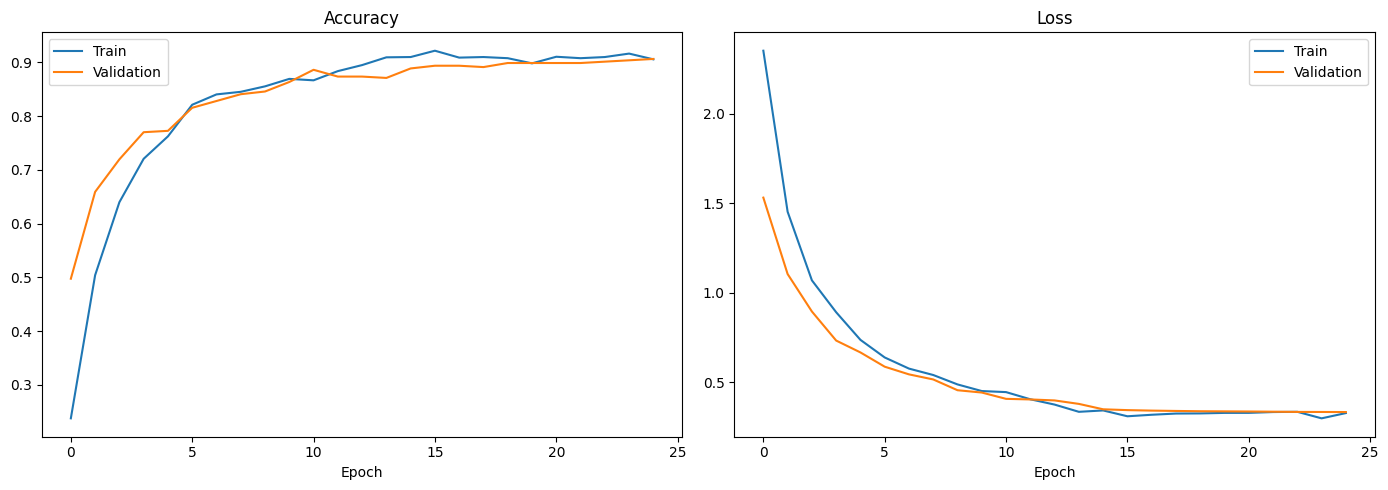

In [16]:
def combine(h1, h2, key):
    return h1.history[key] + h2.history[key]

acc = combine(history1, history2, 'accuracy')
val_acc = combine(history1, history2, 'val_accuracy')
loss = combine(history1, history2, 'loss')
val_loss = combine(history1, history2, 'val_loss')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(acc, label='Train'); axes[0].plot(val_acc, label='Validation')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(loss, label='Train'); axes[1].plot(val_loss, label='Validation')
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout()
plt.show()


## Step 10 — Evaluate on the test set

This is the number that matters most — the test set was never used to
train or tune the model, so this is the closest thing to an honest
real-world accuracy estimate. The confusion matrix shows *which*
denominations get mixed up with each other, which is usually more useful
for your report than accuracy alone.

13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.8889 - loss: 0.3982
Test accuracy: 88.89%
13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 500ms/step
              precision    recall  f1-score   support

   fifty_new       0.94      0.83      0.88        41
   fifty_old       0.90      0.75      0.82        36
five_hundred       0.91      0.93      0.92        43
 hundred_new       0.86      0.89      0.87        35
 hundred_old       0.92      0.71      0.80        17
     ten_new       0.78      0.98      0.87        53
     ten_old       0.87      0.83      0.85        47
  twenty_new       0.91      0.95      0.93        44
  twenty_old       0.93      1.00      0.96        40
 two_hundred       0.92      0.83      0.88        42
two_thousand       1.00      1.00      1.00        16

    accuracy                           0.89       414
   macro avg       0.90      0.88      0.89       414
weighted avg       0.89      0.89      0.89       414



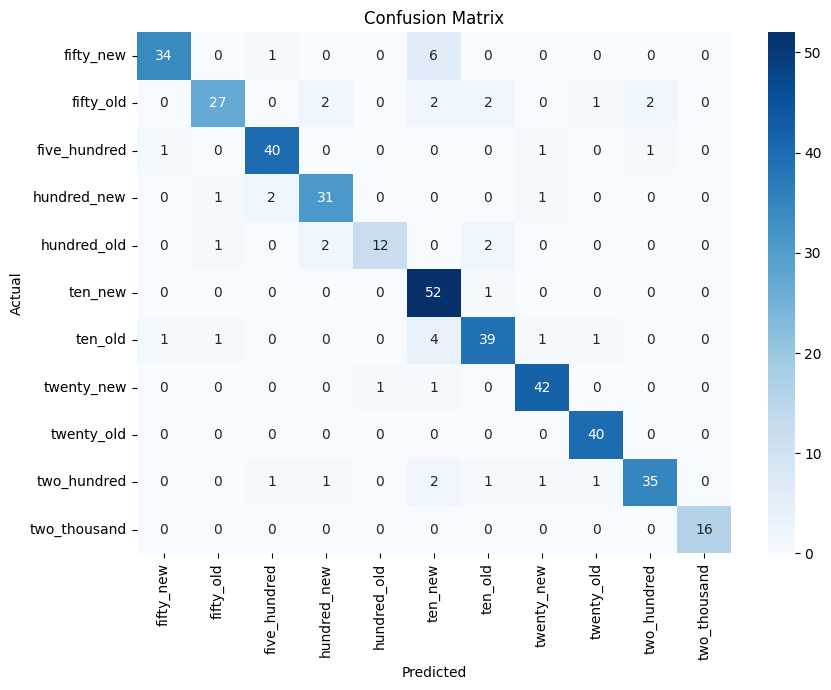

In [17]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test accuracy: {test_acc*100:.2f}%")

y_true = np.concatenate([y.numpy() for x, y in test_ds])
y_true = np.argmax(y_true, axis=1)
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_true, y_pred, target_names=class_names, labels=list(range(NUM_CLASSES))))

cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

## Step 11 — End-to-end sanity check (classification + security info)

This mirrors exactly what the Streamlit app will do: predict a
denomination, then look up the official RBI security-feature checklist for
it. Upload `security_features.py` (from the project files you already
have) when prompted.

In [18]:
from google.colab import files
print("Upload security_features.py (from the project package)")
uploaded = files.upload()


Upload security_features.py (from the project package)


Saving security_features.py to security_features.py


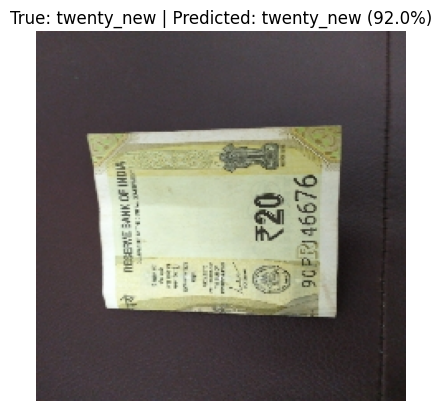

null


In [19]:
from security_features import get_security_info

sample_class = random.choice(class_names)
sample_dir = pathlib.Path(SPLIT_DIR) / 'test' / sample_class
sample_img_path = next(sample_dir.glob('*.*'))

img = tf.keras.utils.load_img(sample_img_path, target_size=IMG_SIZE)
arr = tf.keras.utils.img_to_array(img)
# Updated to match MobileNetV3 preprocessing
arr = tf.keras.applications.mobilenet_v3.preprocess_input(arr)
arr = np.expand_dims(arr, 0)

pred = model.predict(arr, verbose=0)[0]
pred_label = class_names[np.argmax(pred)]
confidence = pred.max()

plt.imshow(img); plt.axis('off')
plt.title(f"True: {sample_class} | Predicted: {pred_label} ({confidence*100:.1f}%)")
plt.show()

info = get_security_info(pred_label)
print(json.dumps(info, indent=2))

## Step 12 — Save the trained model for deployment

`.keras` is TensorFlow's native format and is what `app.py` (the Streamlit
app) expects. We also save `class_names.json` so the app knows the exact
label order the model was trained with.

In [20]:
model.save('currency_model.keras')

with open('class_names.json', 'w') as f:
    json.dump(class_names, f)

print("Saved: currency_model.keras, class_names.json")


Saved: currency_model.keras, class_names.json


In [21]:
from google.colab import files
files.download('currency_model.keras')
files.download('class_names.json')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Next step — deployment

Download `currency_model.keras` and `class_names.json` above, put them in
the same folder as `app.py` and `security_features.py`, then follow the
**README.md** in the project package to run the Streamlit app locally and
deploy it for free on Streamlit Community Cloud.